# NFL Draft Model
## College Statistics Analysis

This notebook explores the relationship between college statistics and NFL success. Before engineering features for the model we examine which college stats correlate most strongly with w_av, how performance varies by position, and which statistics are most useful as predictive signals.

---

### Setup & Data Load

In [1]:
%pip install matplotlib seaborn pandas==2.2.2 --prefer-binary


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install pyarrow --prefer-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 32.2 MB/s  0:00:01m0:00:0100:01

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


---

### Imports & Data Load

In [7]:
%pip install numpy==1.26.4 --prefer-binary

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 19.1 MB/s  0:00:00m0:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Read with fastparquet directly and resave with pyarrow
import fastparquet as fp
import pandas as pd
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(project_root, "data", "processed")

# Read with fastparquet
pf = fp.ParquetFile(os.path.join(processed_path, "final_dataset.parquet"))
df = pf.to_pandas()

# Resave with pyarrow
df.to_parquet(os.path.join(processed_path, "final_dataset.parquet"), 
              engine='pyarrow', index=False)

print(f"Resaved successfully: {df.shape}")
print(df.head(2))

Resaved successfully: (2826, 113)
   season_draft  round  pick team_draft     gsis_id pfr_player_id  \
0          2010      1     1        STL  00-0027854      BradSa00   
1          2010      1     2        DET  00-0027855      SuhxNd99   

     cfb_player_id pfr_player_name    hof position_draft  ...    pfr_id  \
0   sam-bradford-1    Sam Bradford  False             QB  ...  BradSa00   
1  ndamukong-suh-1   Ndamukong Suh  False             DT  ...  SuhxNd99   

  draft_year   ht     wt  forty  bench  vertical  broad_jump  cone  shuttle  
0     2010.0  6-4  236.0   4.79    NaN       NaN         NaN   NaN      NaN  
1     2010.0  6-4  307.0   5.03   32.0      35.5       105.0  7.21     4.44  

[2 rows x 113 columns]


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(project_root, "data", "processed")
figures_path = os.path.join(project_root, "outputs", "figures")

os.makedirs(figures_path, exist_ok=True)

df = pd.read_parquet(os.path.join(processed_path, "final_dataset.parquet"), engine='pyarrow')

print(f"Dataset shape: {df.shape}")
print(f"\nPosition breakdown:")
print(df['position_draft'].value_counts().head(15))
print(f"\nw_av stats:")
print(df['w_av'].describe())

Dataset shape: (2826, 113)

Position breakdown:
position_draft
WR     355
DB     282
LB     262
DE     253
RB     238
DT     215
T      196
CB     178
TE     159
G      139
S      125
QB     115
C       66
OLB     66
OL      50
Name: count, dtype: int64

w_av stats:
count    2826.000000
mean       18.034678
std        20.891889
min        -4.000000
25%         3.000000
50%        10.000000
75%        27.000000
max       140.000000
Name: w_av, dtype: float64


Dataset loaded successfully — 2,826 draft picks from 2010-2021 with 113 columns. Position breakdown is well distributed across all major positions. Now let's explore which college statistics correlate most strongly with NFL success measured by w_av.

---

### Correlation Between College Stats and NFL Success
Which college statistics have the strongest relationship with w_av?

College Stat Correlations with w_av:
                   correlation
passing_TD               0.238
passing_YDS              0.177
passing_PCT              0.114
receiving_TD             0.104
defensive_TFL            0.097
receiving_REC            0.090
rushing_TD               0.090
receiving_YDS            0.088
defensive_TOT            0.088
rushing_YPC              0.082
defensive_SACKS          0.077
rushing_YDS              0.067
defensive_SOLO           0.067
rushing_CAR              0.049
passing_YPA              0.045
receiving_YPR            0.031
interceptions_INT        0.024
defensive_PD             0.018


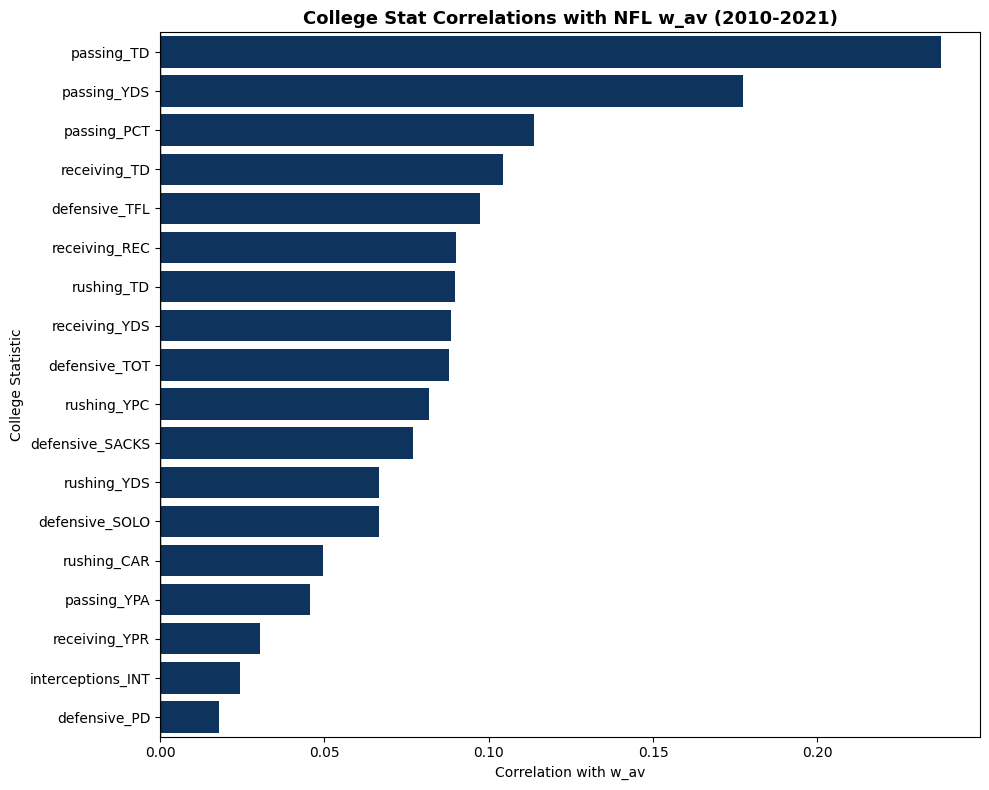

In [2]:
# College stat columns
college_stat_cols = [
    'passing_YDS', 'passing_TD', 'passing_PCT', 'passing_YPA',
    'rushing_YDS', 'rushing_TD', 'rushing_YPC', 'rushing_CAR',
    'receiving_YDS', 'receiving_REC', 'receiving_TD', 'receiving_YPR',
    'defensive_SOLO', 'defensive_SACKS', 'defensive_TFL', 'defensive_TOT',
    'defensive_PD', 'interceptions_INT'
]

# Calculate correlations with w_av
correlations = {}
for col in college_stat_cols:
    if col in df.columns:
        valid = df[[col, 'w_av']].dropna()
        if len(valid) > 50:
            corr = valid[col].corr(valid['w_av'])
            correlations[col] = corr

corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['correlation'])
corr_df = corr_df.sort_values('correlation', ascending=False)

print("College Stat Correlations with w_av:")
print(corr_df.round(3).to_string())

plt.figure(figsize=(10, 8))
colors = ['#013369' if x > 0 else '#D50A0A' for x in corr_df['correlation']]
sns.barplot(data=corr_df.reset_index(), x='correlation', y='index',
            hue='index',
            palette=dict(zip(corr_df.index, colors)),
            legend=False)
plt.axvline(x=0, color='black', linewidth=1)
plt.title('College Stat Correlations with NFL w_av (2010-2021)', fontsize=13, fontweight='bold')
plt.xlabel('Correlation with w_av')
plt.ylabel('College Statistic')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "college_stat_correlations.png"), dpi=150, bbox_inches='tight')
plt.show()

![College Stat Correlations](../outputs/figures/college_stat_correlations.png)

All college statistics show positive correlation with NFL w_av — more production in college correlates with more NFL success across every metric. Key findings:

**Strongest predictors:**
- **Passing TDs (0.238)** — the strongest single college stat predictor of NFL success
- **Passing yards (0.177)** — volume passing production translates well
- **Completion percentage (0.114)** — accuracy in college predicts NFL success
- **Receiving TDs (0.104)** — touchdown production for receivers is predictive

**Moderate predictors:**
- **Tackles for loss (0.097)** — disruptive defensive players translate well
- **Receiving receptions and yards (0.088-0.090)** — volume receiving stats matter
- **Rushing TDs and YPC (0.082-0.090)** — efficiency and scoring for RBs

**Weakest predictors:**
- **Interceptions and pass deflections (0.018-0.024)** — defensive back stats translate poorly
- **Receiving YPR (0.031)** — efficiency alone without volume is less predictive

The correlations are all positive but relatively modest — individual stats alone are weak predictors. The model will need to combine multiple features to generate meaningful predictions.

---

### Correlations by Position Group
Do certain stats predict success better for specific positions?

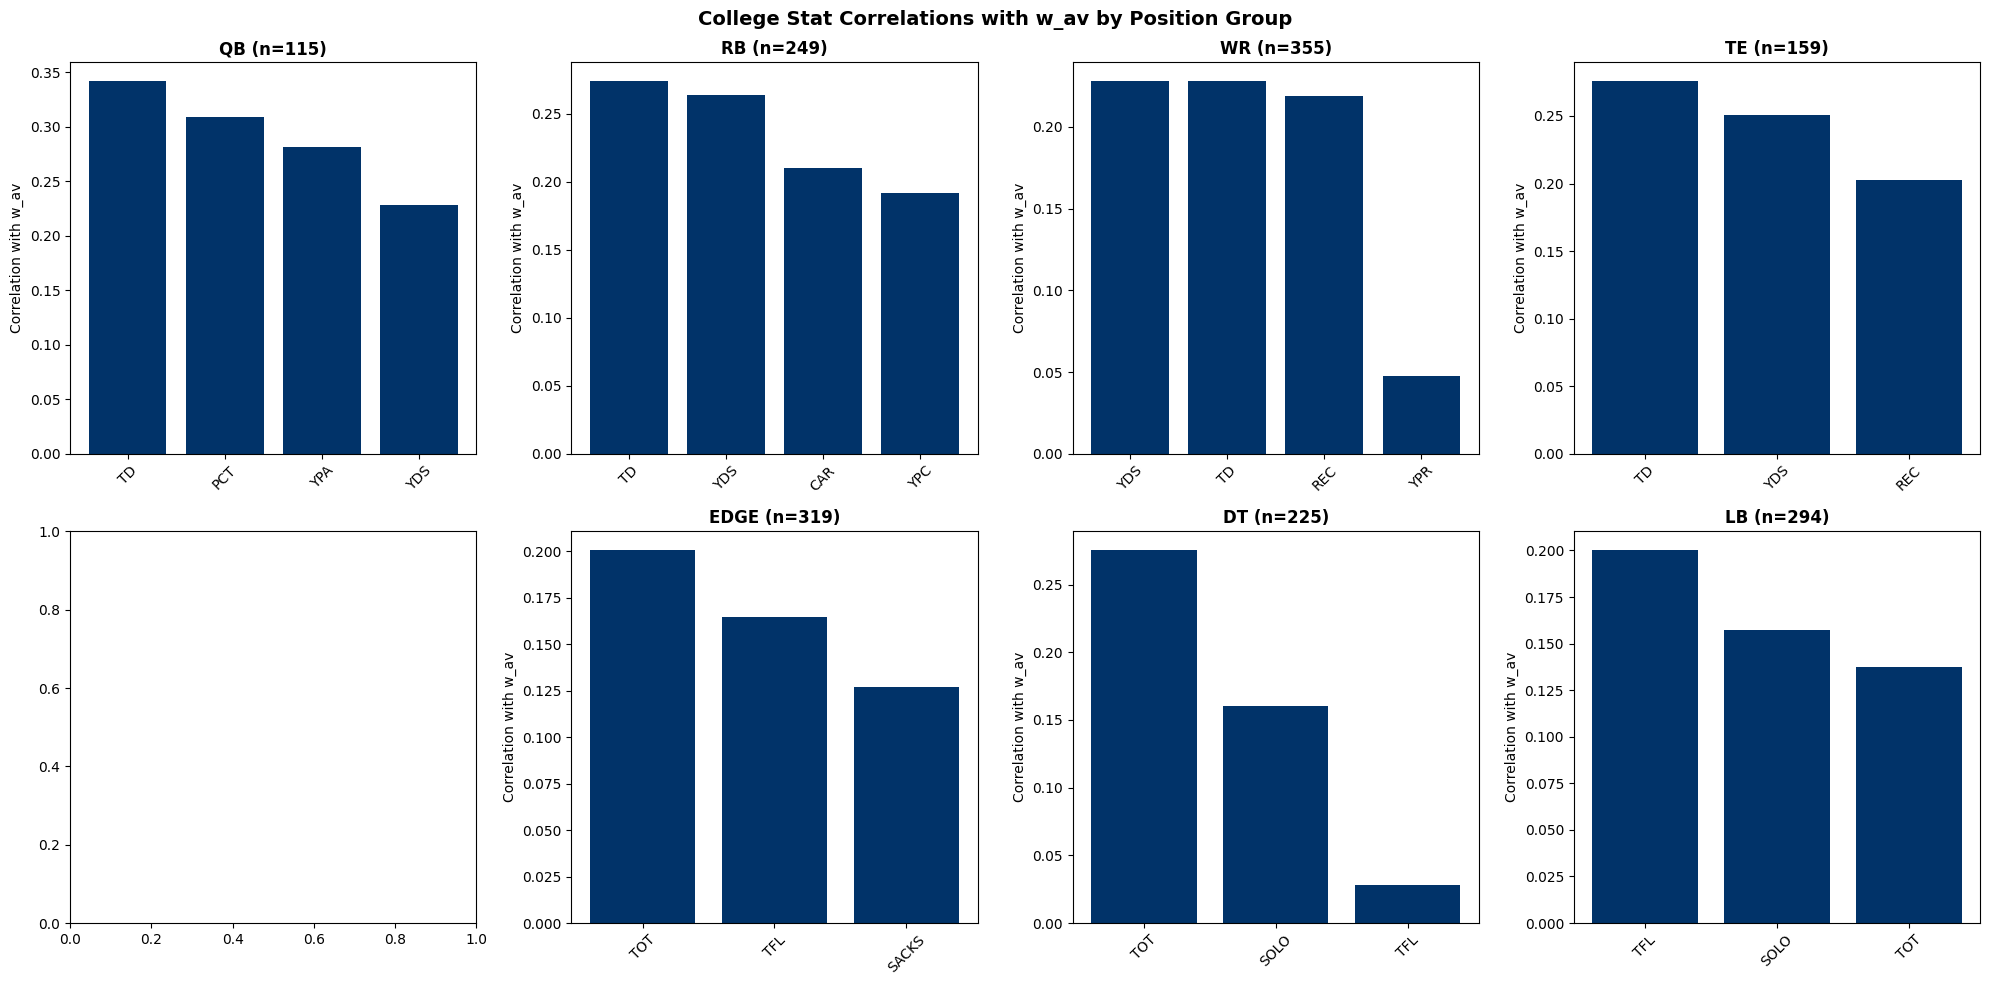

In [3]:
# Define position groups
position_groups = {
    'QB': ['QB'],
    'RB': ['RB', 'FB'],
    'WR': ['WR'],
    'TE': ['TE'],
    'OL': ['T', 'G', 'C', 'OL', 'OT', 'OG'],
    'EDGE': ['DE', 'OLB'],
    'DT': ['DT', 'NT'],
    'LB': ['LB', 'ILB', 'MLB'],
    'DB': ['CB', 'S', 'DB', 'FS', 'SS']
}

position_stats = {
    'QB': ['passing_YDS', 'passing_TD', 'passing_PCT', 'passing_YPA'],
    'RB': ['rushing_YDS', 'rushing_TD', 'rushing_YPC', 'rushing_CAR'],
    'WR': ['receiving_YDS', 'receiving_REC', 'receiving_TD', 'receiving_YPR'],
    'TE': ['receiving_YDS', 'receiving_REC', 'receiving_TD'],
    'EDGE': ['defensive_SACKS', 'defensive_TFL', 'defensive_TOT'],
    'DT': ['defensive_TFL', 'defensive_TOT', 'defensive_SOLO'],
    'LB': ['defensive_TOT', 'defensive_SOLO', 'defensive_TFL'],
    'DB': ['defensive_SOLO', 'defensive_PD', 'interceptions_INT']
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (pos_group, positions) in enumerate(list(position_groups.items())[:8]):
    pos_df = df[df['position_draft'].isin(positions)].copy()
    
    if pos_group in position_stats:
        stats = position_stats[pos_group]
        corrs = {}
        for stat in stats:
            if stat in pos_df.columns:
                valid = pos_df[[stat, 'w_av']].dropna()
                if len(valid) > 20:
                    corrs[stat.split('_')[1]] = valid[stat].corr(valid['w_av'])
        
        if corrs:
            corr_series = pd.Series(corrs).sort_values(ascending=False)
            colors = ['#013369' if x > 0 else '#D50A0A' for x in corr_series.values]
            axes[idx].bar(corr_series.index, corr_series.values, color=colors)
            axes[idx].set_title(f'{pos_group} (n={len(pos_df)})', fontweight='bold')
            axes[idx].set_ylabel('Correlation with w_av')
            axes[idx].axhline(y=0, color='black', linewidth=0.5)
            axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('College Stat Correlations with w_av by Position Group', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "position_correlations.png"), dpi=150, bbox_inches='tight')
plt.show()

![Position Correlations](../outputs/figures/position_correlations.png)

The position-specific correlations are significantly stronger than the overall correlations, confirming that position-specific modeling will outperform a single model across all positions.

**Key findings by position:**

**QB (n=115):** TD passes (0.34) and completion percentage (0.31) are the strongest predictors — accuracy and scoring efficiency translate most reliably to NFL success

**RB (n=249):** Touchdowns (0.28) and yards (0.27) lead — volume and scoring production matter most, YPC efficiency is less predictive than raw production

**WR (n=355):** Yards (0.28), TDs (0.27), and receptions (0.23) are all similarly predictive — volume metrics dominate, YPR efficiency barely matters (0.05)

**TE (n=159):** TDs (0.28) and yards (0.26) lead — scoring and production translate well for tight ends

**EDGE (n=319):** Total tackles (0.20) and TFL (0.17) are stronger than sacks (0.13) — overall disruptiveness predicts better than pure pass rush numbers

**DT (n=225):** Total tackles dominate (0.27) — interior linemen who show up in the stat sheet consistently translate to NFL success

**LB (n=294):** TFL (0.20) and solo tackles (0.16) — linebackers who make plays behind the line of scrimmage translate best

**OL chart is empty** — offensive linemen have no individual college stats tracked, which is one of the hardest positions to evaluate from data alone

---

### Combine Measurables Correlation with w_av
How predictive are physical measurables from the NFL combine?

Combine Measurables Correlations with w_av:
            correlation
bench             0.141
wt                0.129
ht_inches         0.118
forty             0.045
shuttle           0.038
cone              0.030
broad_jump       -0.028
vertical         -0.030


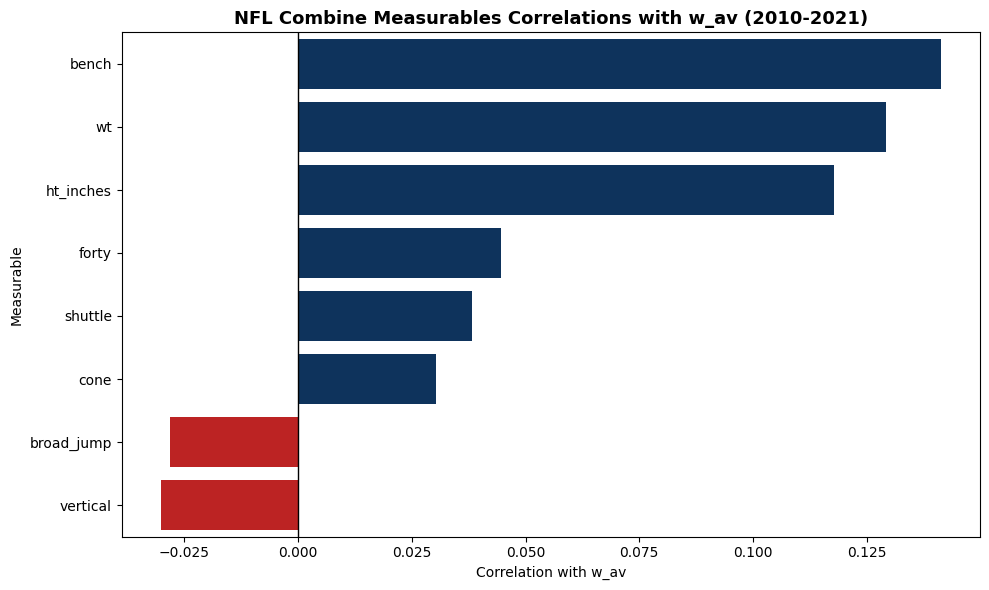

In [4]:
# Combine measurables correlation with w_av
combine_cols = ['ht', 'wt', 'forty', 'bench', 'vertical', 'broad_jump', 'cone', 'shuttle']

# Convert height to inches first
def height_to_inches(ht):
    if pd.isna(ht):
        return np.nan
    try:
        parts = str(ht).split('-')
        return int(parts[0]) * 12 + int(parts[1])
    except:
        return np.nan

df['ht_inches'] = df['ht'].apply(height_to_inches)

combine_cols_numeric = ['ht_inches', 'wt', 'forty', 'bench', 'vertical', 'broad_jump', 'cone', 'shuttle']

combine_corrs = {}
for col in combine_cols_numeric:
    if col in df.columns:
        valid = df[[col, 'w_av']].dropna()
        if len(valid) > 100:
            corr = valid[col].corr(valid['w_av'])
            combine_corrs[col] = corr

combine_corr_df = pd.DataFrame.from_dict(combine_corrs, orient='index', columns=['correlation'])
combine_corr_df = combine_corr_df.sort_values('correlation', ascending=False)

print("Combine Measurables Correlations with w_av:")
print(combine_corr_df.round(3).to_string())

plt.figure(figsize=(10, 6))
colors = ['#013369' if x > 0 else '#D50A0A' for x in combine_corr_df['correlation']]
sns.barplot(data=combine_corr_df.reset_index(), x='correlation', y='index',
            hue='index',
            palette=dict(zip(combine_corr_df.index, colors)),
            legend=False)
plt.axvline(x=0, color='black', linewidth=1)
plt.title('NFL Combine Measurables Correlations with w_av (2010-2021)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Correlation with w_av')
plt.ylabel('Measurable')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "combine_correlations.png"), dpi=150, bbox_inches='tight')
plt.show()

![Combine Correlations](../outputs/figures/combine_correlations.png)

The combine measurables tell a fascinating story — size matters far more than speed and athleticism when predicting NFL success:

**Strongest predictors:**
- **Bench press (0.141)** — strength is the most predictive combine measurable, reflecting that physical power translates across positions
- **Weight (0.129)** — heavier players tend to have longer, more productive NFL careers
- **Height (0.118)** — taller players generate more career value on average

**Weak positive predictors:**
- **40 yard dash (0.045)** — raw speed has a surprisingly weak positive correlation with career value
- **Shuttle (0.038)** and **Cone (0.030)** — agility drills barely predict success

**Negative predictors:**
- **Broad jump (-0.028)** and **Vertical (-0.030)** — explosion metrics actually correlate negatively with career value

**Why does size dominate?** The positive correlation of bench, weight, and height reflects positional bias — linemen and tight ends are the heaviest, tallest, and strongest players and also tend to accumulate the most career value due to longevity. Speed and explosion metrics are more important for skill positions but those players have shorter careers and lower total w_av.

**The key insight for modeling:** Combine measurables are most useful when analyzed within position groups, not across all positions together. A 4.3 40 time means something very different for a cornerback vs a tight end.

---

### Summary
This notebook establishes the predictive signal available from college stats and combine measurables:

1. **Passing TDs and yards are the strongest college predictors** of NFL success overall
2. **Position-specific correlations are 2-3x stronger** than overall correlations — the model must be position-aware
3. **Size metrics (bench, weight, height) outperform speed and athleticism** at the overall level due to positional bias
4. **OL is the hardest position to evaluate** — no individual college stats are tracked
5. **The combined signal from college stats and combine data is meaningful** but modest — draft evaluation remains inherently difficult